## 1. Imports

In [20]:
import time
import random
import sys
import statistics
import tracemalloc
from collections import deque

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

sys.setrecursionlimit(50000)

## 2. Graph Generators

Graphs are represented as **adjacency lists** using dictionaries: `{vertex: [neighbours]}`.

There are generated several types of graphs to study how structure affects DFS/BFS performance:
- **Random graph** — each possible edge exists with probability *p*
- **Sparse graph** — a spanning tree plus a few extra edges
- **Dense graph** — high edge probability (~0.5)
- **Complete graph** — every vertex connected to every other
- **Tree** — exactly *n − 1* edges, no cycles
- **Disconnected graph** — several isolated components

In [21]:
def generate_random_graph(n, edge_prob=0.01, seed=None):
    """Generate a random undirected graph with *n* vertices."""
    if seed is not None:
        random.seed(seed)
    graph = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < edge_prob:
                graph[i].append(j)
                graph[j].append(i)
    return graph


def generate_sparse_graph(n, extra_edges_factor=0.1, seed=None):
    """Spanning tree + a few extra edges."""
    if seed is not None:
        random.seed(seed)
    graph = {i: [] for i in range(n)}
    # Build a random spanning tree
    vertices = list(range(n))
    random.shuffle(vertices)
    for idx in range(1, n):
        u = vertices[idx]
        v = vertices[random.randint(0, idx - 1)]
        graph[u].append(v)
        graph[v].append(u)
    # Add extra edges
    extra = int(n * extra_edges_factor)
    for _ in range(extra):
        u, v = random.randint(0, n - 1), random.randint(0, n - 1)
        if u != v and v not in graph[u]:
            graph[u].append(v)
            graph[v].append(u)
    return graph


def generate_dense_graph(n, edge_prob=0.5, seed=None):
    """Dense random graph."""
    return generate_random_graph(n, edge_prob=edge_prob, seed=seed)


def generate_complete_graph(n):
    """Complete graph K_n."""
    graph = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(n):
            if i != j:
                graph[i].append(j)
    return graph


def generate_tree(n, seed=None):
    """Random tree with *n* vertices (n-1 edges)."""
    if seed is not None:
        random.seed(seed)
    graph = {i: [] for i in range(n)}
    vertices = list(range(n))
    random.shuffle(vertices)
    for idx in range(1, n):
        u = vertices[idx]
        v = vertices[random.randint(0, idx - 1)]
        graph[u].append(v)
        graph[v].append(u)
    return graph


def generate_disconnected_graph(n, components=5, seed=None):
    """Graph split into *components* disconnected sub-trees."""
    if seed is not None:
        random.seed(seed)
    graph = {i: [] for i in range(n)}
    # Distribute vertices into components
    comp_sizes = [n // components] * components
    for i in range(n % components):
        comp_sizes[i] += 1
    offset = 0
    for size in comp_sizes:
        verts = list(range(offset, offset + size))
        random.shuffle(verts)
        for idx in range(1, len(verts)):
            u = verts[idx]
            v = verts[random.randint(0, idx - 1)]
            graph[u].append(v)
            graph[v].append(u)
        offset += size
    return graph


def count_edges(graph):
    """Count total edges in an undirected graph."""
    return sum(len(adj) for adj in graph.values()) // 2

## 2.5 Graph Structure Visualization

Small instances (n ≈ 10) of each graph type, drawn with a circular layout so connectivity patterns are clearly visible.

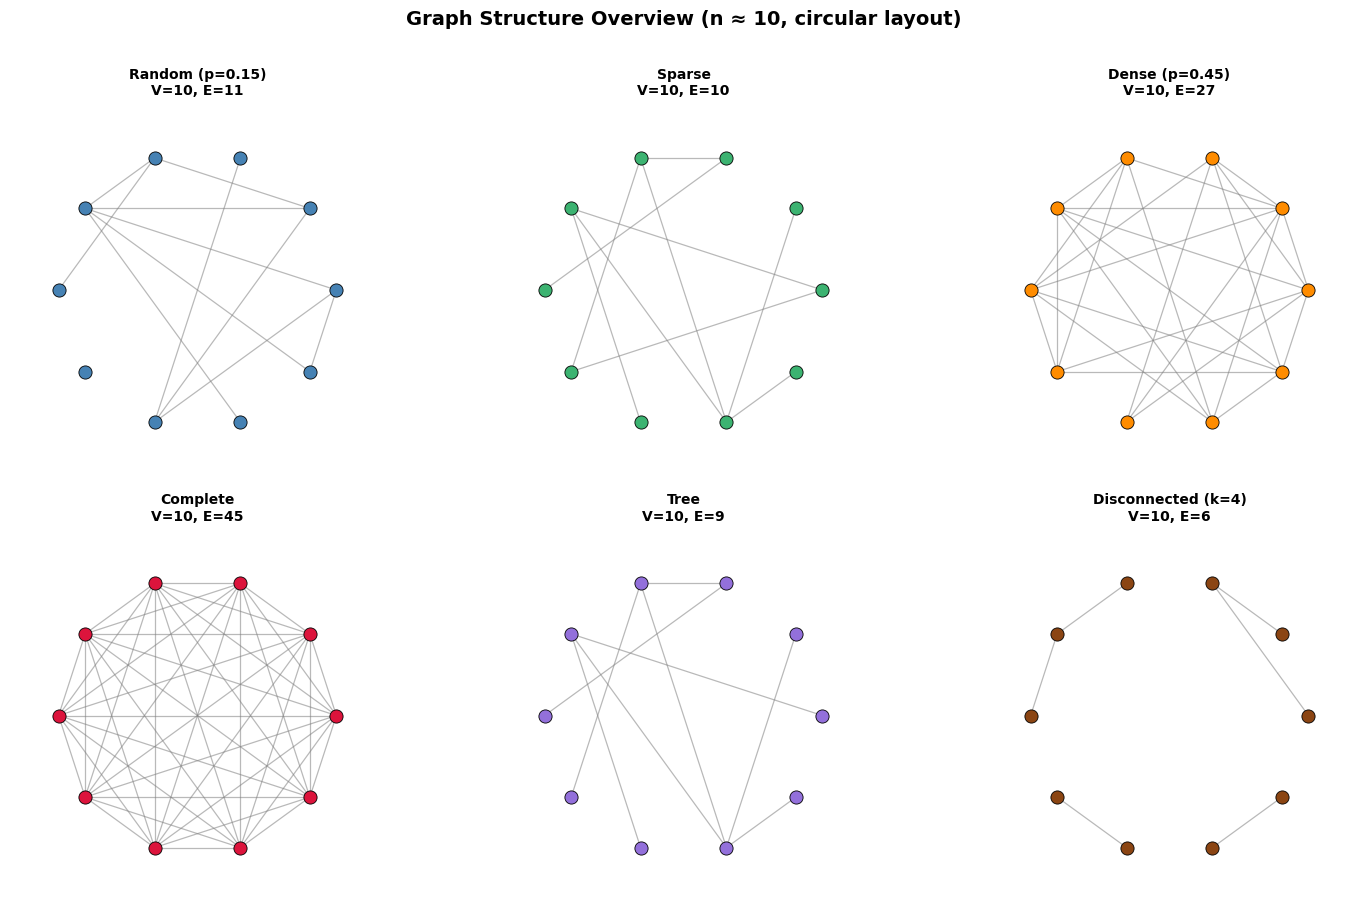

In [22]:
import math

def _circular_layout(nodes):
    """Place *nodes* evenly on a unit circle."""
    n = len(nodes)
    return {
        node: (math.cos(2 * math.pi * i / n), math.sin(2 * math.pi * i / n))
        for i, node in enumerate(nodes)
    }

def _draw_graph_type(ax, graph, title, node_color, edge_alpha=0.55):
    nodes = list(graph)
    pos   = _circular_layout(nodes)
    drawn = set()
    for u in graph:
        for v in graph[u]:
            key = (min(u, v), max(u, v))
            if key not in drawn:
                drawn.add(key)
                ax.plot(
                    [pos[u][0], pos[v][0]],
                    [pos[u][1], pos[v][1]],
                    color="gray", linewidth=0.9, alpha=edge_alpha, zorder=1,
                )
    xs = [pos[nd][0] for nd in nodes]
    ys = [pos[nd][1] for nd in nodes]
    ax.scatter(xs, ys, s=90, c=node_color, zorder=2,
               edgecolors="black", linewidths=0.6)
    e = count_edges(graph)
    ax.set_title(f"{title}\nV={len(nodes)}, E={e}", fontsize=10, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)


_N_VIZ = 10   # small enough to see structure clearly

_viz_graphs = [
    ("Random (p=0.15)",      generate_random_graph(_N_VIZ, edge_prob=0.15,  seed=7),  "steelblue"),
    ("Sparse",               generate_sparse_graph(_N_VIZ, seed=7),                   "mediumseagreen"),
    ("Dense (p=0.45)",       generate_random_graph(_N_VIZ, edge_prob=0.45,  seed=7),  "darkorange"),
    ("Complete",             generate_complete_graph(10),                              "crimson"),
    ("Tree",                 generate_tree(_N_VIZ, seed=7),                            "mediumpurple"),
    ("Disconnected (k=4)",   generate_disconnected_graph(_N_VIZ, components=4, seed=7), "saddlebrown"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (title, graph, color) in zip(axes.flat, _viz_graphs):
    _draw_graph_type(ax, graph, title, color)

fig.suptitle("Graph Structure Overview (n ≈ 10, circular layout)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 3. Algorithm Implementations

### 3.1 DFS — Iterative

In [23]:
def dfs_iterative(graph, start=0):
    visited = set()
    order = []
    stack = [start]

    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        order.append(node)
        # Push neighbours in reverse so that the leftmost neighbour is visited first
        for neighbour in reversed(graph[node]):
            if neighbour not in visited:
                stack.append(neighbour)

    return order

### 3.2 DFS — Recursive

In [24]:
def dfs_recursive(graph, start=0):
    visited = set()
    order = []

    def _dfs(node):
        visited.add(node)
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                _dfs(neighbour)

    _dfs(start)
    return order

### 3.3 BFS

In [25]:
def bfs(graph, start=0):
    visited = set()
    order = []
    queue = deque([start])
    visited.add(start)

    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)

    return order

### 3.5 Optimized Traversals

**Improvements over the classical versions:**
- **DFS marks visited at push time** — eliminates duplicate stack entries, reducing stack pressure and wasted pops.
- **BFS marks visited at enqueue time** — same benefit for the queue.
- **Hot-path method aliases** — `visited.add`, `order.append`, `stack.pop/append`, `queue.popleft/append` are bound to locals once, avoiding repeated attribute lookups inside the loop.
- **No format-conversion overhead** — works directly on adjacency dicts like all other functions in this notebook.
- **`traverse_all` flag** — iterates over all nodes as roots to cover disconnected graphs.
- Asymptotic complexity stays **O(V + E)**; gains are in constant factors.

In [26]:
def dfs_iterative_optimized(graph, start=0, traverse_all=False):
    visited = set()
    order = []
    visited_add = visited.add
    order_append = order.append
    roots = graph if traverse_all else [start]

    for root in roots:
        if root in visited:
            continue
        visited_add(root)
        stack = [root]
        stack_pop = stack.pop
        stack_append = stack.append

        while stack:
            node = stack_pop()
            order_append(node)
            for nb in reversed(graph[node]):
                if nb not in visited:
                    visited_add(nb)
                    stack_append(nb)

    return order


def bfs_optimized(graph, start=0, traverse_all=False):
    visited = set()
    order = []
    visited_add = visited.add
    order_append = order.append
    roots = graph if traverse_all else [start]

    for root in roots:
        if root in visited:
            continue
        visited_add(root)
        queue = deque([root])
        dequeue = queue.popleft
        enqueue = queue.append

        while queue:
            node = dequeue()
            order_append(node)
            for nb in graph[node]:
                if nb not in visited:
                    visited_add(nb)
                    enqueue(nb)

    return order

## 4. Input Data Properties

The analysis is performed against the following input-data properties:

| Property | Values tested |
|---|---|
| **Number of vertices (V)** | 100 → 10 000 |
| **Edge density** | Sparse (tree-like) → Dense (p ≈ 0.5) |
| **Graph structure** | Random, Tree, Sparse, Dense, Complete, Disconnected |

---

## 5. Metrics for Comparison

| Metric | How measured |
|---|---|
| **Execution time** | `time.perf_counter()` (wall-clock, high resolution) |
| **Peak memory usage** | `tracemalloc` (peak bytes allocated during traversal) |
| **Nodes visited** | Length of the returned traversal list |

## 6. Benchmarking Framework

In [27]:
def benchmark(algorithm, graph, start=0, runs=3):
    times = []
    memories = []
    visited_count = 0

    for _ in range(runs):
        tracemalloc.start()
        t0 = time.perf_counter()

        result = algorithm(graph, start)

        t1 = time.perf_counter()
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        times.append(t1 - t0)
        memories.append(peak)
        visited_count = len(result)

    mean_t = sum(times) / len(times)
    std_t  = statistics.stdev(times) if len(times) > 1 else 0.0

    return {
        "time":     mean_t,
        "time_std": std_t,
        "memory":   int(sum(memories) / len(memories)),
        "visited":  visited_count,
    }


ALGORITHMS = [
    ("DFS Iterative", dfs_iterative),
    ("DFS Recursive", dfs_recursive),
    ("BFS",           bfs),
]

COLORS = {
    "DFS Iterative": "steelblue",
    "DFS Recursive": "darkorange",
    "BFS":           "crimson",
}

### 6.1 Optimized vs Classical — Direct Benchmark Comparison

We run both classic and optimized variants on the same graphs and plot the speedup factor.

  n=   500  [Sparse (p≈tree)]  DFS Iterative: 0.274ms→0.187ms (1.47×)  BFS: 0.139ms→0.142ms (0.98×)
  n=   500  [Dense  (p=0.3)]  DFS Iterative: 8.478ms→6.250ms (1.36×)  BFS: 2.454ms→2.766ms (0.89×)
  n=  1000  [Sparse (p≈tree)]  DFS Iterative: 0.497ms→0.617ms (0.80×)  BFS: 0.717ms→0.784ms (0.91×)
  n=  1000  [Dense  (p=0.3)]  DFS Iterative: 41.951ms→22.300ms (1.88×)  BFS: 19.681ms→18.577ms (1.06×)
  n=  2000  [Sparse (p≈tree)]  DFS Iterative: 1.881ms→1.073ms (1.75×)  BFS: 0.711ms→0.718ms (0.99×)
  n=  2000  [Dense  (p=0.3)]  DFS Iterative: 148.222ms→65.413ms (2.27×)  BFS: 55.207ms→55.352ms (1.00×)
  n=  5000  [Sparse (p≈tree)]  DFS Iterative: 2.763ms→2.865ms (0.96×)  BFS: 1.577ms→1.608ms (0.98×)
  n=  5000  [Dense  (p=0.3)]  DFS Iterative: 1218.122ms→633.406ms (1.92×)  BFS: 580.052ms→574.701ms (1.01×)
  n= 10000  [Sparse (p≈tree)]  DFS Iterative: 5.911ms→4.183ms (1.41×)  BFS: 4.542ms→4.441ms (1.02×)
  n= 10000  [Dense  (p=0.3)]  DFS Iterative: 5930.847ms→2018.814ms (2.94×)  BFS: 1713.

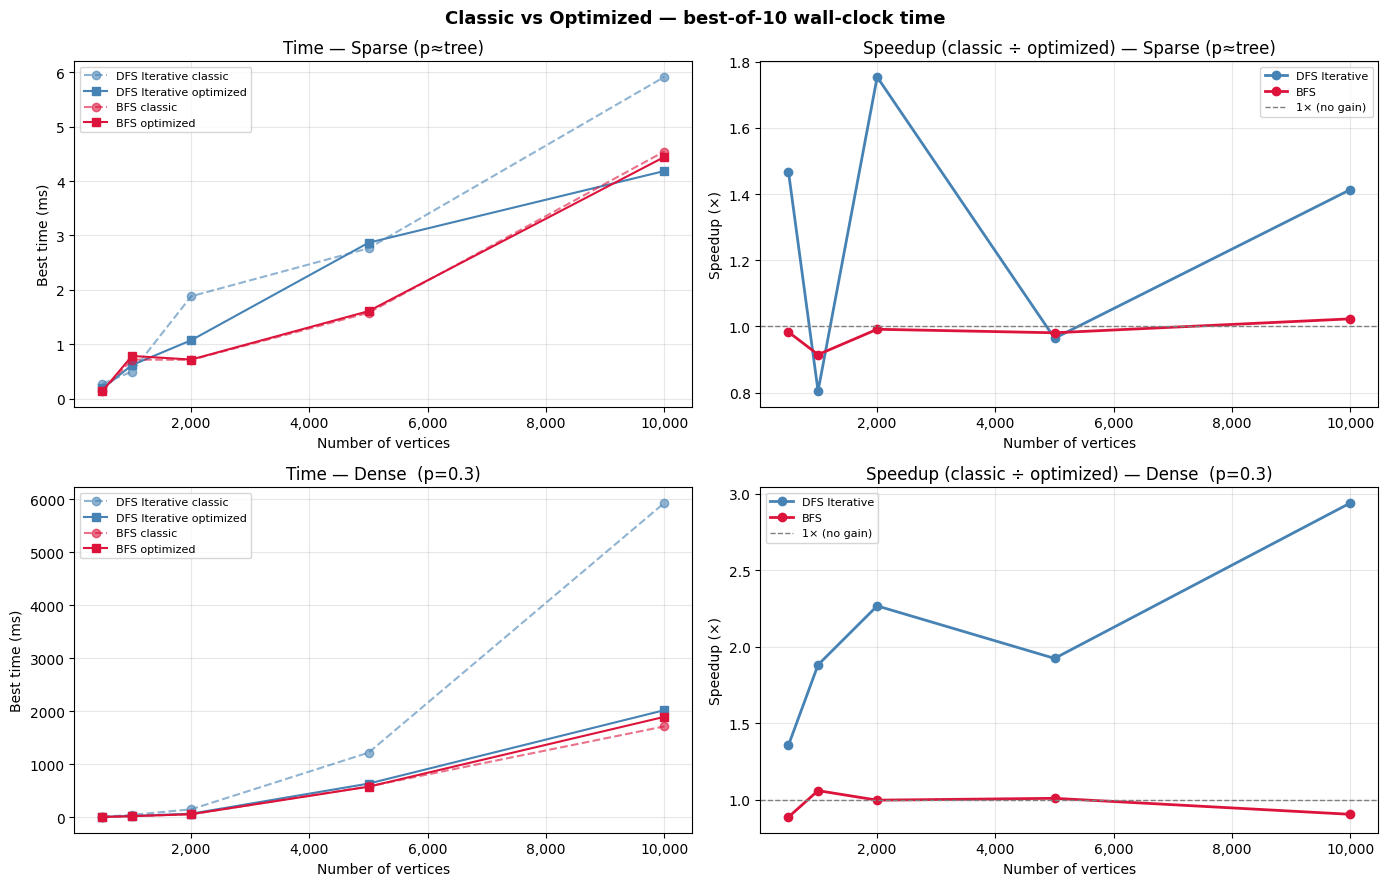

In [28]:
def time_it(fn, graph, start=0, runs=10):
    """Pure wall-clock timing — no tracemalloc overhead."""
    best = float("inf")
    for _ in range(runs):
        t0 = time.perf_counter()
        fn(graph, start)
        best = min(best, time.perf_counter() - t0)
    return best  # best-of-N removes scheduling noise

compare_pairs = [
    ("DFS Iterative", dfs_iterative,          "DFS Optimized", dfs_iterative_optimized),
    ("BFS",           bfs,                    "BFS Optimized", bfs_optimized),
]
colors_cmp = {"DFS Iterative": "steelblue", "BFS": "crimson"}

# Test on both sparse AND dense graphs — optimisation shows most on dense
graph_types = [
    ("Sparse (p≈tree)", lambda n: generate_sparse_graph(n, seed=42)),
    ("Dense  (p=0.3)",  lambda n: generate_random_graph(n, edge_prob=0.3, seed=42)),
]
compare_sizes = [500, 1000, 2000, 5000, 10000]

all_timings = {}   # (graph_label, cls_name) -> {classic, optimized, speedup}
for g_label, g_fn in graph_types:
    for cls_name, *_ in compare_pairs:
        all_timings[(g_label, cls_name)] = {"classic": [], "optimized": [], "speedup": []}

for n in compare_sizes:
    for g_label, g_fn in graph_types:
        g = g_fn(n)
        row = f"  n={n:>6}  [{g_label}]"
        for cls_name, cls_fn, opt_name, opt_fn in compare_pairs:
            t_cls = time_it(cls_fn, g)
            t_opt = time_it(opt_fn, g)
            sp = t_cls / t_opt if t_opt > 0 else float("nan")
            all_timings[(g_label, cls_name)]["classic"].append(t_cls)
            all_timings[(g_label, cls_name)]["optimized"].append(t_opt)
            all_timings[(g_label, cls_name)]["speedup"].append(sp)
            row += f"  {cls_name}: {t_cls*1000:.3f}ms→{t_opt*1000:.3f}ms ({sp:.2f}×)"
        print(row)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row_idx, (g_label, _) in enumerate(graph_types):
    # Left: absolute times
    ax = axes[row_idx][0]
    for cls_name, *_ in compare_pairs:
        td = all_timings[(g_label, cls_name)]
        ax.plot(compare_sizes, [t * 1000 for t in td["classic"]],
                marker="o", linestyle="--", color=colors_cmp[cls_name],
                alpha=0.6, label=cls_name + " classic")
        ax.plot(compare_sizes, [t * 1000 for t in td["optimized"]],
                marker="s", linestyle="-", color=colors_cmp[cls_name],
                label=cls_name + " optimized")
    ax.set_title(f"Time — {g_label}", fontsize=12)
    ax.set_xlabel("Number of vertices")
    ax.set_ylabel("Best time (ms)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # Right: speedup factor
    ax = axes[row_idx][1]
    for cls_name, *_ in compare_pairs:
        td = all_timings[(g_label, cls_name)]
        ax.plot(compare_sizes, td["speedup"],
                marker="o", color=colors_cmp[cls_name], linewidth=2, label=cls_name)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="1× (no gain)")
    ax.set_title(f"Speedup (classic ÷ optimized) — {g_label}", fontsize=12)
    ax.set_xlabel("Number of vertices")
    ax.set_ylabel("Speedup (×)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Classic vs Optimized — best-of-10 wall-clock time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Experiment 1 — Varying Graph Size (Low-Density Random Graphs)

We fix edge probability at `p = 0.005` (low-density Erdős–Rényi random graph) and sweep vertex count from 100 to 10 000.  
This shows how each algorithm scales with **V** while keeping edge density roughly constant.

**Expected:** linear time growth. DFS Recursive may fail with `RecursionError` on very deep instances despite the raised limit.

In [29]:
sizes_exp1    = [100, 500, 1000, 2000, 3000, 5000, 7500, 10000]
edge_prob_exp1 = 0.005  # low-density random graph

results_exp1 = {
    name: {"time": [], "time_std": [], "memory": [], "visited": []}
    for name, _ in ALGORITHMS
}

for n in sizes_exp1:
    graph = generate_random_graph(n, edge_prob=edge_prob_exp1, seed=42)
    print(f"  n={n:>6}  edges={count_edges(graph):>10,}", end="")
    for name, func in ALGORITHMS:
        try:
            res = benchmark(func, graph, start=0)
        except RecursionError:
            res = {"time": float("nan"), "time_std": 0.0, "memory": 0, "visited": 0}
        results_exp1[name]["time"].append(res["time"])
        results_exp1[name]["time_std"].append(res["time_std"])
        results_exp1[name]["memory"].append(res["memory"])
        results_exp1[name]["visited"].append(res["visited"])
    print("  ✓")

print("Experiment 1 done.")

  n=   100  edges=        20  ✓
  n=   500  edges=       605  ✓
  n=  1000  edges=     2,495  ✓
  n=  2000  edges=     9,941  ✓
  n=  3000  edges=    22,340  ✓
  n=  5000  edges=    62,048  ✓
  n=  7500  edges=   140,149  ✓
  n= 10000  edges=   250,012  ✓
Experiment 1 done.


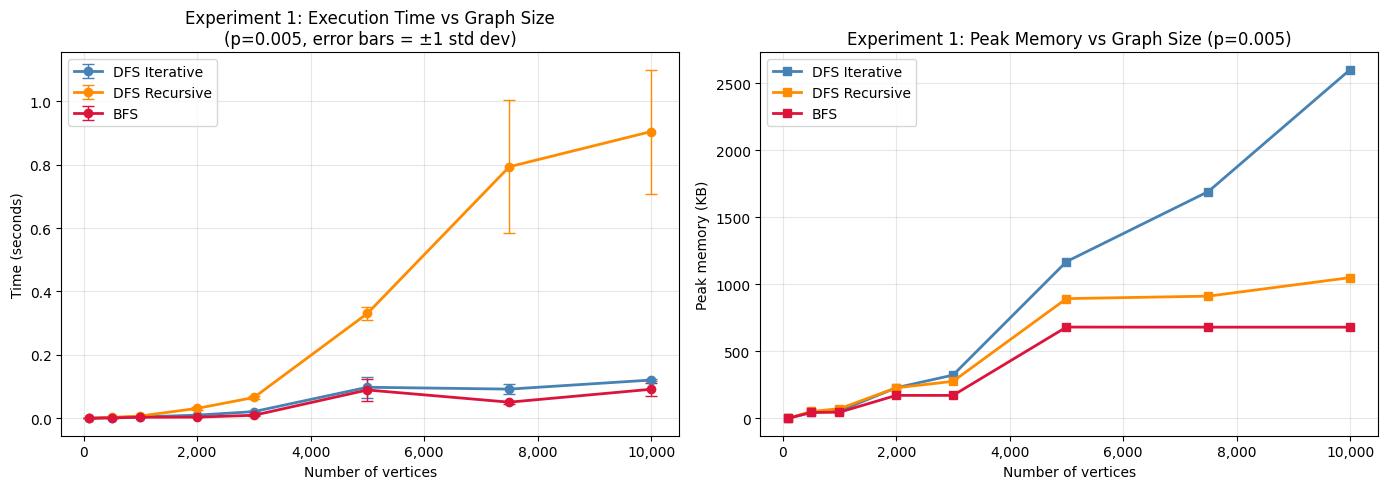

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, _ in ALGORITHMS:
    ax.errorbar(
        sizes_exp1,
        results_exp1[name]["time"],
        yerr=results_exp1[name]["time_std"],
        marker="o", label=name, color=COLORS[name],
        linewidth=2, capsize=4, elinewidth=1,
    )
ax.set_title("Experiment 1: Execution Time vs Graph Size\n(p=0.005, error bars = ±1 std dev)", fontsize=12)
ax.set_xlabel("Number of vertices")
ax.set_ylabel("Time (seconds)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax = axes[1]
for name, _ in ALGORITHMS:
    mem_kb = [m / 1024 for m in results_exp1[name]["memory"]]
    ax.plot(sizes_exp1, mem_kb,
            marker="s", label=name, color=COLORS[name], linewidth=2)
ax.set_title("Experiment 1: Peak Memory vs Graph Size (p=0.005)", fontsize=12)
ax.set_xlabel("Number of vertices")
ax.set_ylabel("Peak memory (KB)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

## 8. Experiment 2 — Varying Edge Density (Fixed Size)

We fix the number of vertices and increase the edge probability to study how graph density affects performance.

In [31]:
n_exp2 = 2000
edge_probs = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]

# Only iterative DFS and BFS (recursive DFS may hit recursion limits on dense graphs)
algos_exp2 = [
    ("DFS Iterative", dfs_iterative),
    ("BFS",           bfs),
]

results_exp2 = {name: {"time": [], "memory": [], "edges": []} for name, _ in algos_exp2}

for p in edge_probs:
    graph = generate_random_graph(n_exp2, edge_prob=p, seed=42)
    e = count_edges(graph)
    print(f"  p={p:<6}  edges={e:>10,}", end="")
    for name, func in algos_exp2:
        res = benchmark(func, graph, start=0)
        results_exp2[name]["time"].append(res["time"])
        results_exp2[name]["memory"].append(res["memory"])
        results_exp2[name]["edges"].append(e)
    print("  ✓")

print("Experiment 2 done.")

  p=0.001   edges=     1,910  ✓
  p=0.005   edges=     9,941  ✓
  p=0.01    edges=    19,931  ✓
  p=0.02    edges=    40,043  ✓
  p=0.05    edges=    99,819  ✓
  p=0.1     edges=   200,031  ✓
  p=0.2     edges=   399,720  ✓
  p=0.3     edges=   599,750  ✓
  p=0.5     edges=   999,109  ✓
Experiment 2 done.


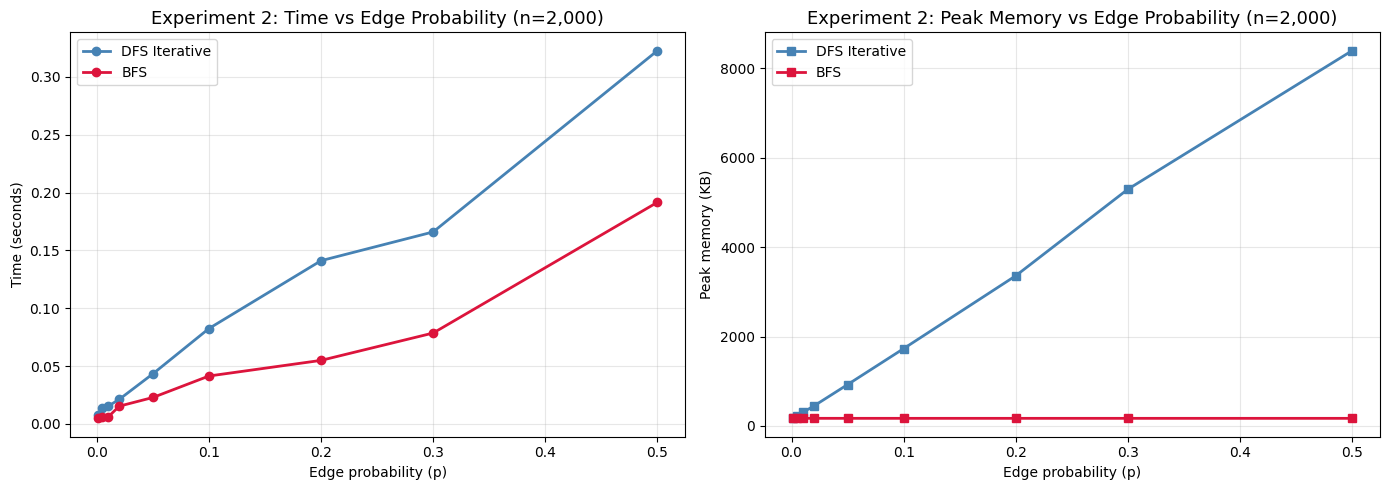

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, _ in algos_exp2:
    ax.plot(edge_probs, results_exp2[name]["time"],
            marker='o', label=name, color=COLORS[name], linewidth=2)
ax.set_title(f"Experiment 2: Time vs Edge Probability (n={n_exp2:,})", fontsize=13)
ax.set_xlabel("Edge probability (p)")
ax.set_ylabel("Time (seconds)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for name, _ in algos_exp2:
    mem_kb = [m / 1024 for m in results_exp2[name]["memory"]]
    ax.plot(edge_probs, mem_kb,
            marker='s', label=name, color=COLORS[name], linewidth=2)
ax.set_title(f"Experiment 2: Peak Memory vs Edge Probability (n={n_exp2:,})", fontsize=13)
ax.set_xlabel("Edge probability (p)")
ax.set_ylabel("Peak memory (KB)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Experiment 3 — Different Graph Structures

Fixed `n = 3000`, comparing DFS Iterative vs BFS across six structures.

> **Disconnected graph:** both algorithms start from vertex 0 and only visit its component — this is correct single-source behaviour. Use `dfs_iterative_optimized(..., traverse_all=True)` for full coverage.

In [33]:
n_exp3 = 3000

structures = [
    ("Tree",             generate_tree(n_exp3, seed=42)),
    ("Sparse",           generate_sparse_graph(n_exp3, seed=42)),
    ("Random (p=0.01)",  generate_random_graph(n_exp3, 0.01, seed=42)),
    ("Dense (p=0.3)",    generate_random_graph(n_exp3, 0.3,  seed=42)),
    ("Complete",         generate_complete_graph(500)),   # smaller n due to O(n²) edges
    ("Disconnected",     generate_disconnected_graph(n_exp3, components=10, seed=42)),
]

algos_exp3 = [
    ("DFS Iterative", dfs_iterative),
    ("BFS",           bfs),
]

results_exp3  = {name: {"time": [], "memory": []} for name, _ in algos_exp3}
structure_names = []

for struct_name, graph in structures:
    structure_names.append(struct_name)
    n_actual = len(graph)
    e_actual = count_edges(graph)
    print(f"  {struct_name:<20}  V={n_actual:,}  E={e_actual:,}", end="")
    for name, func in algos_exp3:
        res = benchmark(func, graph, start=0)
        results_exp3[name]["time"].append(res["time"])
        results_exp3[name]["memory"].append(res["memory"])
    visited_dfs = benchmark(dfs_iterative, graph, start=0, runs=1)["visited"]
    print(f"  visited={visited_dfs:,}  ✓")

print("Experiment 3 done.")

  Tree                  V=3,000  E=2,999  visited=3,000  ✓
  Sparse                V=3,000  E=3,298  visited=3,000  ✓
  Random (p=0.01)       V=3,000  E=44,700  visited=3,000  ✓
  Dense (p=0.3)         V=3,000  E=1,349,951  visited=3,000  ✓
  Complete              V=500  E=124,750  visited=500  ✓
  Disconnected          V=3,000  E=2,990  visited=300  ✓
Experiment 3 done.


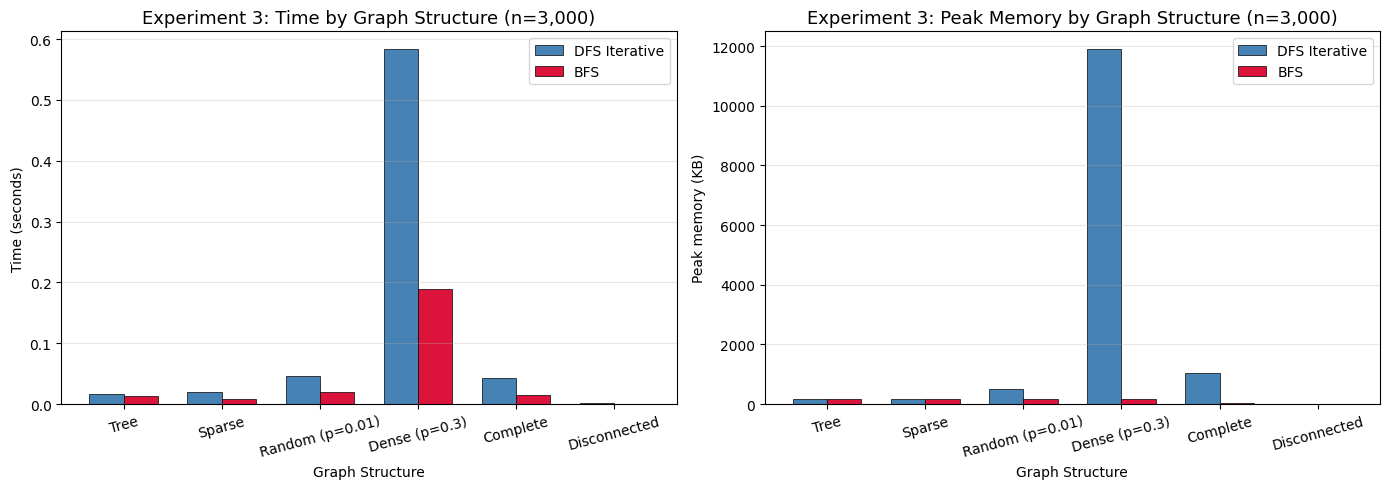

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(structure_names))
bar_w = 0.35

ax = axes[0]
for idx, (name, _) in enumerate(algos_exp3):
    offset = (idx - 0.5) * bar_w
    ax.bar(x + offset, results_exp3[name]["time"],
           width=bar_w, label=name, color=COLORS[name], edgecolor='black', linewidth=0.5)
ax.set_title(f"Experiment 3: Time by Graph Structure (n={n_exp3:,})", fontsize=13)
ax.set_xlabel("Graph Structure")
ax.set_ylabel("Time (seconds)")
ax.set_xticks(x)
ax.set_xticklabels(structure_names, rotation=15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
for idx, (name, _) in enumerate(algos_exp3):
    offset = (idx - 0.5) * bar_w
    mem_kb = [m / 1024 for m in results_exp3[name]["memory"]]
    ax.bar(x + offset, mem_kb,
           width=bar_w, label=name, color=COLORS[name], edgecolor='black', linewidth=0.5)
ax.set_title(f"Experiment 3: Peak Memory by Graph Structure (n={n_exp3:,})", fontsize=13)
ax.set_xlabel("Graph Structure")
ax.set_ylabel("Peak memory (KB)")
ax.set_xticks(x)
ax.set_xticklabels(structure_names, rotation=15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. Experiment 4 — Complete Graph (Small Sizes)

Complete graphs have $\frac{n(n-1)}{2}$ edges — they grow quadratically, so we test smaller sizes.

In [35]:
sizes_exp4 = [50, 100, 200, 500, 1000, 1500, 2000]

algos_exp4 = [
    ("DFS Iterative", dfs_iterative),
    ("BFS",           bfs),
]

results_exp4 = {name: {"time": [], "memory": []} for name, _ in algos_exp4}

for n in sizes_exp4:
    graph = generate_complete_graph(n)
    print(f"  Complete K_{n:<5}  edges={count_edges(graph):>10,}", end="")
    for name, func in algos_exp4:
        res = benchmark(func, graph, start=0)
        results_exp4[name]["time"].append(res["time"])
        results_exp4[name]["memory"].append(res["memory"])
    print("  ✓")

print("Experiment 4 done.")

  Complete K_50     edges=     1,225  ✓
  Complete K_100    edges=     4,950  ✓
  Complete K_200    edges=    19,900  ✓
  Complete K_500    edges=   124,750  ✓
  Complete K_1000   edges=   499,500  ✓
  Complete K_1500   edges= 1,124,250  ✓
  Complete K_2000   edges= 1,999,000  ✓
Experiment 4 done.


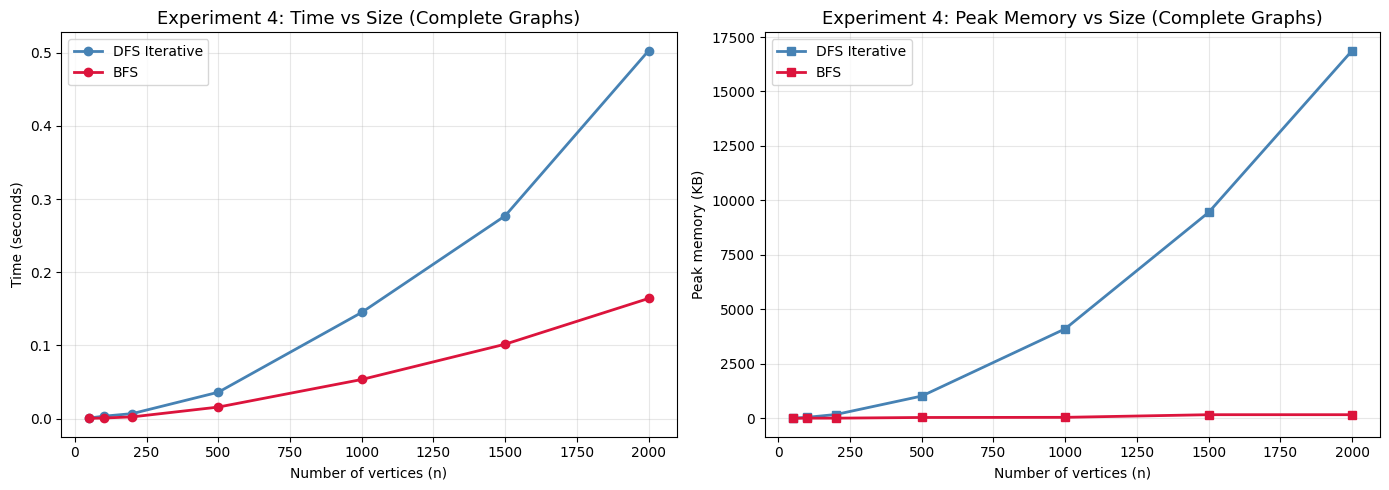

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, _ in algos_exp4:
    ax.plot(sizes_exp4, results_exp4[name]["time"],
            marker='o', label=name, color=COLORS[name], linewidth=2)
ax.set_title("Experiment 4: Time vs Size (Complete Graphs)", fontsize=13)
ax.set_xlabel("Number of vertices (n)")
ax.set_ylabel("Time (seconds)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for name, _ in algos_exp4:
    mem_kb = [m / 1024 for m in results_exp4[name]["memory"]]
    ax.plot(sizes_exp4, mem_kb,
            marker='s', label=name, color=COLORS[name], linewidth=2)
ax.set_title("Experiment 4: Peak Memory vs Size (Complete Graphs)", fontsize=13)
ax.set_xlabel("Number of vertices (n)")
ax.set_ylabel("Peak memory (KB)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Traversal Visualization on a Small Graph

We draw a small graph and show the order in which DFS and BFS visit each node.

C:\Users\Acer\AppData\Local\Temp\ipykernel_3016\4006982629.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


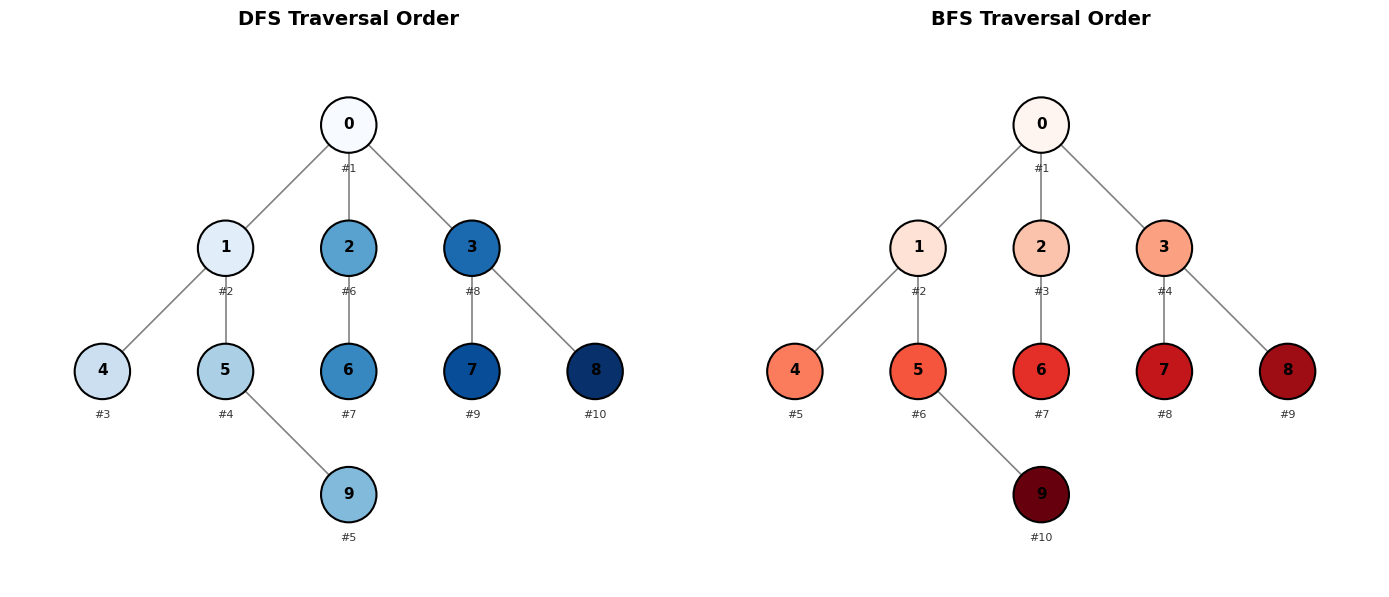

DFS order: [0, 1, 4, 5, 9, 2, 6, 3, 7, 8]
BFS order: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [37]:
vis_graph = {
    0: [1, 2, 3],
    1: [0, 4, 5],
    2: [0, 6],
    3: [0, 7, 8],
    4: [1],
    5: [1, 9],
    6: [2],
    7: [3],
    8: [3],
    9: [5],
}

# layered layout — BFS from root, each depth level is one row
def compute_layout(graph, root=0):
    from collections import deque
    layers = {}  # node -> depth
    q = deque([root])
    layers[root] = 0
    while q:
        node = q.popleft()
        for nb in graph[node]:
            if nb not in layers:
                layers[nb] = layers[node] + 1
                q.append(nb)

    depth_groups = {}
    for node, d in layers.items():
        depth_groups.setdefault(d, []).append(node)

    pos = {}
    for d, nodes in depth_groups.items():
        nodes.sort()
        width = len(nodes)
        for i, node in enumerate(nodes):
            pos[node] = ((i - (width - 1) / 2) * 2.0, -d * 2.0)
    return pos

def draw_graph(ax, graph, pos, order, title, cmap_name='YlOrRd'):
    import matplotlib.cm as cm
    n = len(order)
    cmap = cm.get_cmap(cmap_name, n)
    order_map = {node: idx for idx, node in enumerate(order)}

    # draw edges
    drawn = set()
    for u in graph:
        for v in graph[u]:
            edge = (min(u, v), max(u, v))
            if edge not in drawn:
                drawn.add(edge)
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                        color='gray', linewidth=1.2, zorder=1)

    # draw nodes with visit-order label below
    for node in graph:
        idx = order_map.get(node, n - 1)
        x, y = pos[node]
        circle = plt.Circle((x, y), 0.45, color=cmap(idx / max(n - 1, 1)),
                             ec='black', linewidth=1.5, zorder=2)
        ax.add_patch(circle)
        ax.text(x, y + 0.02, str(node), ha='center', va='center',
                fontsize=11, fontweight='bold', zorder=3)
        ax.text(x, y - 0.7, f"#{idx + 1}", ha='center', va='center',
                fontsize=8, color='#333333', zorder=3)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.axis('off')
    margin = 1.5
    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - margin, max(xs) + margin)
    ax.set_ylim(min(ys) - margin, max(ys) + margin)


pos = compute_layout(vis_graph, root=0)
dfs_order = dfs_iterative(vis_graph, 0)
bfs_order = bfs(vis_graph, 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
draw_graph(axes[0], vis_graph, pos, dfs_order, "DFS Traversal Order", cmap_name='Blues')
draw_graph(axes[1], vis_graph, pos, bfs_order, "BFS Traversal Order", cmap_name='Reds')
plt.tight_layout()
plt.show()

print(f"DFS order: {dfs_order}")
print(f"BFS order: {bfs_order}")

## 12. Results Summary Table

In [38]:
def print_table(title, headers, rows):
    col_widths = [
        max(len(str(h)), max(len(str(r[i])) for r in rows))
        for i, h in enumerate(headers)
    ]
    sep         = "+-" + "-+-".join("-" * w for w in col_widths) + "-+"
    header_line = "| " + " | ".join(str(h).ljust(w) for h, w in zip(headers, col_widths)) + " |"

    print(f"\n{title}")
    print(sep)
    print(header_line)
    print(sep)
    for row in rows:
        print("| " + " | ".join(str(v).ljust(w) for v, w in zip(row, col_widths)) + " |")
    print(sep)


# Experiment 1 — size scaling
rows1 = []
for i, n in enumerate(sizes_exp1):
    for name, _ in ALGORITHMS:
        t   = results_exp1[name]["time"][i]
        std = results_exp1[name]["time_std"][i]
        m   = results_exp1[name]["memory"][i]
        v   = results_exp1[name]["visited"][i]
        rows1.append([n, name, f"{t:.6f}", f"±{std:.6f}", f"{m:,}", v])

print_table(
    "EXPERIMENT 1: Varying Graph Size (p=0.005 random graph)",
    ["Vertices", "Algorithm", "Time (s)", "Std Dev (s)", "Memory (B)", "Visited"],
    rows1,
)

# Experiment 2 — density sweep
rows2 = []
for i, p in enumerate(edge_probs):
    for name, _ in algos_exp2:
        t = results_exp2[name]["time"][i]
        m = results_exp2[name]["memory"][i]
        e = results_exp2[name]["edges"][i]
        rows2.append([f"{p}", f"{e:,}", name, f"{t:.6f}", f"{m:,}"])

print_table(
    f"EXPERIMENT 2: Varying Edge Density (n={n_exp2:,})",
    ["Prob", "Edges", "Algorithm", "Time (s)", "Memory (B)"],
    rows2,
)

# Experiment 3 — graph structures
rows3 = []
for i, sname in enumerate(structure_names):
    for name, _ in algos_exp3:
        t = results_exp3[name]["time"][i]
        m = results_exp3[name]["memory"][i]
        rows3.append([sname, name, f"{t:.6f}", f"{m:,}"])

print_table(
    "EXPERIMENT 3: Different Graph Structures",
    ["Structure", "Algorithm", "Time (s)", "Memory (B)"],
    rows3,
)


EXPERIMENT 1: Varying Graph Size (p=0.005 random graph)
+----------+---------------+----------+-------------+------------+---------+
| Vertices | Algorithm     | Time (s) | Std Dev (s) | Memory (B) | Visited |
+----------+---------------+----------+-------------+------------+---------+
| 100      | DFS Iterative | 0.000025 | ±0.000019   | 386        | 1       |
| 100      | DFS Recursive | 0.000015 | ±0.000005   | 616        | 1       |
| 100      | BFS           | 0.000014 | ±0.000007   | 1,112      | 1       |
| 500      | DFS Iterative | 0.002413 | ±0.000589   | 45,552     | 436     |
| 500      | DFS Recursive | 0.002764 | ±0.000732   | 52,312     | 436     |
| 500      | BFS           | 0.001245 | ±0.000496   | 44,696     | 436     |
| 1000     | DFS Iterative | 0.004215 | ±0.001049   | 56,208     | 990     |
| 1000     | DFS Recursive | 0.007289 | ±0.001095   | 73,672     | 990     |
| 1000     | BFS           | 0.003291 | ±0.000621   | 46,816     | 990     |
| 2000     | DFS It